<a href="https://colab.research.google.com/github/eduardodpms/UnB_Notebooks/blob/main/24.1%20TEMA/Trabalho%202/trabalho2_tema.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Segundo Trabalho de Tópicos Especiais em Matemática Aplicada - 25/09/2024**

Integrantes do Grupo:
*   231034494 - Eduardo de Pina Moreira Santos
*   231026812 - Felipe de Castro Quixabeira




Neste trabalho, o objetivo é praticar a aplicação de 4 dos classificadores ensinados em sala de aula, os quais se encontram disponíveis na biblioteca *Scikit-learn*. São eles:
1.  Regressão Logística;
2.  Análise do Discriminante Linear;
3.  Análise do Discriminante Quadrático;
4.  Naive Bayes Gaussiano.

Para isso, serão utilizadas duas bases de dados provenientes do *Keras*, o *MNIST* e o *CIFAR10*. Cada uma será empregada para treinar 4 diferentes modelos, cada um utilizando um dos classificadores.

Depois, a fim de aplicar os modelos, desenvolve-se a previsão dos mesmos com a biblioteca padrão de 10 mil imagens do *Keras*, e compara-se com os dados verdadeiros para obter uma ou mais métricas que avaliam o desempenho do classificador.

In [ ]:
import numpy as np
import seaborn as sns
import pandas as pd
from sklearn import preprocessing as pre  # Biblioteca para normalização do conjunto de dados
from sklearn import metrics as met  # Biblioteca que fornece um conjunto de 4 métricas importantes para posterior comparação dos resultados
from matplotlib import pyplot as plt

In [ ]:
# Esses vetores vão armazenar as acurácias (nesse caso, são equivalentes ao Score) de cada classificador, para comparação no final da atividade

acc_mnist = []
acc_cifar10 = []

# **MNIST**

O *MNIST* é uma biblioteca do *Keras* que fornece 60 mil imagens de dimensão 28x28, cujos pixels possuem um valor de claridade de 0 (preto) a 255 (branco). Cada imagem é a representação de um dos 10 dígitos decimais. Além disso, ela fornece também um vetor adicional com 10 mil imagens dedicadas ao teste do modelo.

Nesse sentido, o objetivo será treinar 4 modelos do *sklearn* referentes aos 4 classificadores, para classificar as 10 mil imagens de teste.

In [ ]:
from keras.datasets import mnist
(x_train, y_train),(x_test, y_test) = mnist.load_data()

In [ ]:
print(f'X de Treino: {x_train.shape}\nY de Treino: {y_train.shape}\nX de Teste: {x_test.shape}\nY de Teste: {y_test.shape}')

X de Treino: (60000, 28, 28)
Y de Treino: (60000,)
X de Teste: (10000, 28, 28)
Y de Teste: (10000,)


Estamos trabalhando com 4 listas, 2 de teste e 2 de treino. As listas "X" possuem dimensão 2 e contém as imagens 28x28, onde os pixels são representados por valores de 0 a 255. As listas "Y", de dimensão 1, contém apenas as etiquetas (labels) das imagens em "X".

Vamos visualizar um exemplo de cada etiqueta disponível:

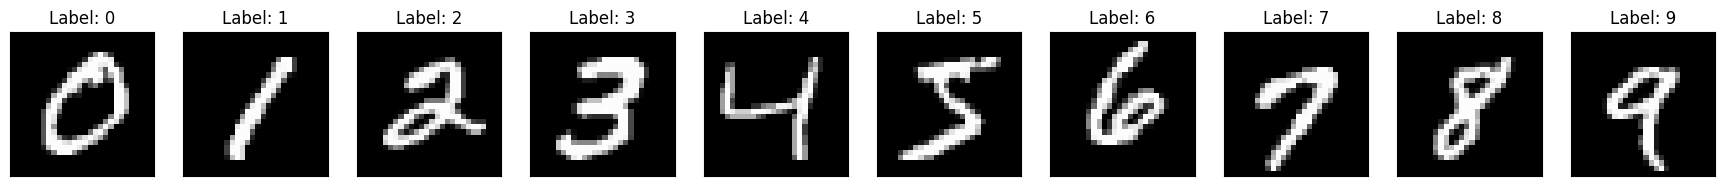

In [ ]:
fig, ax = plt.subplots(1, 10, figsize=(22,22))

for i in range(10):
  sample = x_train[y_train == i][0]
  ax[i].imshow(sample, cmap="gray")
  ax[i].set_title(f"Label: {i}")
  ax[i].get_xaxis().set_visible(False)
  ax[i].get_yaxis().set_visible(False)

Antes de iniciar o treinamento dos classificadores, é importante submeter as "imagens" a um processo de normalização e de remodelação.

* A normalização transformará o nosso conjunto de dados, que varia de 0 a 255, em
um conjunto de dados que varia de 0 a 1, com média 0 e variância 1. Esse processo pode otimizar o treinamento do modelo, em questões de tempo e de processamento.

* A remodelação diminuirá o número de dimensões de "X" de 2 para 1 (de 28x28 para 784), a fim de igualar o número de dimensões com aquele de "Y". Esse processo é necessário para treinar os modelos do *sklearn*.

In [ ]:
scaler = pre.StandardScaler()
scaler.fit(x_train.reshape(60000, 784))

x_train = scaler.transform(x_train.reshape(60000, 784))
x_test = scaler.transform(x_test.reshape(10000, 784))

# Regressão Logística

Para esse classificador em questão, podem ser utilizados diferentes *solvers* e diferentes números de iterações.

Após múltiplos testes, foram utilizados aqueles parâmetros que minimizavam o tempo de processamento e que aumentavam a acurácia.

In [ ]:
from sklearn import linear_model

log_reg = linear_model.LogisticRegression(random_state=0, solver='newton-cg', multi_class='multinomial', penalty='l2', max_iter=200) # Criação do modelo

log_reg.fit(X = x_train, y = y_train) # Treinamento

LogisticRegression(max_iter=200, multi_class='multinomial', random_state=0,
                   solver='newton-cg')

In [ ]:
y_log_reg = log_reg.predict(x_test) # Previsão

In [ ]:
# Métricas de desempenho
log_reg_data = [['Accuracy', met.accuracy_score(y_test, y_log_reg)],
                ['Precision', met.precision_score(y_test, y_log_reg, average='macro')],
                ['Recall', met.recall_score(y_test, y_log_reg, average='macro')],
                ['F1-score', met.f1_score(y_test, y_log_reg, average='macro')]]

acc_mnist.append(f'{log_reg_data[0][1]*100:.2f}%')

for i in range(len(log_reg_data)):
  print(f'{log_reg_data[i][0]}: {log_reg_data[i][1]:.4f}')

Accuracy: 0.9211
Precision: 0.9202
Recall: 0.9200
F1-score: 0.9201


Após treinamento e teste do modelo, foram geradas as métricas de previsão acima. Para fins de padronização, aquela a qual a nossa análise será direcionada será a acurácia (*Accuracy*).

O procedimento realizado se repetirá para os três classificadores faltantes, a fim de agregar as métricas de cada um para posterior comparação.

# Análise do Discriminante Linear

In [ ]:
from sklearn import discriminant_analysis

lin_dis = discriminant_analysis.LinearDiscriminantAnalysis() # Criação do modelo
lin_dis.fit(X = x_train, y = y_train) # Treinamento

LinearDiscriminantAnalysis()

In [ ]:
y_lin_dis = lin_dis.predict(x_test) # Previsão

In [ ]:
# Métricas de desempenho
lin_dis_data = [['Accuracy', met.accuracy_score(y_test, y_lin_dis)],
                ['Precision', met.precision_score(y_test, y_lin_dis, average='macro')],
                ['Recall', met.recall_score(y_test, y_lin_dis, average='macro')],
                ['F1-score', met.f1_score(y_test, y_lin_dis, average='macro')]]

acc_mnist.append(f'{lin_dis_data[0][1]*100:.2f}%')

for i in range(len(lin_dis_data)):
  print(f'{lin_dis_data[i][0]}: {lin_dis_data[i][1]:.4f}')

Accuracy: 0.8730
Precision: 0.8735
Recall: 0.8717
F1-score: 0.8717


# Análise do Discriminante Quadrático

In [ ]:
qua_dis = discriminant_analysis.QuadraticDiscriminantAnalysis() # Criação do modelo
qua_dis.fit(X = x_train, y = y_train) # Treinamento

/usr/local/lib/python3.10/dist-packages/sklearn/discriminant_analysis.py:935: UserWarning: Variables are collinear
  warnings.warn("Variables are collinear")


QuadraticDiscriminantAnalysis()

In [ ]:
y_qua_dis = qua_dis.predict(x_test) # Previsão

In [ ]:
# Métricas de desempenho
qua_dis_data = [['Accuracy', met.accuracy_score(y_test, y_qua_dis)],
           ['Precision', met.precision_score(y_test, y_qua_dis, average='macro')],
           ['Recall', met.recall_score(y_test, y_qua_dis, average='macro')],
           ['F1-score', met.f1_score(y_test, y_qua_dis, average='macro')]]

acc_mnist.append(f'{qua_dis_data[0][1]*100:.2f}%')

for i in range(len(qua_dis_data)):
  print(f'{qua_dis_data[i][0]}: {qua_dis_data[i][1]:.4f}')

Accuracy: 0.5264
Precision: 0.6836
Recall: 0.5197
F1-score: 0.4639


# Naïve Bayes

In [ ]:
from sklearn import naive_bayes

nai_bay = naive_bayes.GaussianNB() # Criação do modelo
nai_bay.fit(X = x_train, y = y_train) # Treinamento

GaussianNB()

In [ ]:
y_nai_bay = nai_bay.predict(x_test) # Previsão

In [ ]:
# Métricas de desempenho
nai_bay_data = [['Accuracy', met.accuracy_score(y_test, y_nai_bay)],
                ['Precision', met.precision_score(y_test, y_nai_bay, average='macro')],
                ['Recall', met.recall_score(y_test, y_nai_bay, average='macro')],
                ['F1-score', met.f1_score(y_test, y_nai_bay, average='macro')]]

acc_mnist.append(f'{nai_bay_data[0][1]*100:.2f}%')

for i in range(len(nai_bay_data)):
  print(f'{nai_bay_data[i][0]}: {nai_bay_data[i][1]:.4f}')

Accuracy: 0.5240
Precision: 0.6699
Recall: 0.5170
F1-score: 0.4692


# Matriz de Confusão

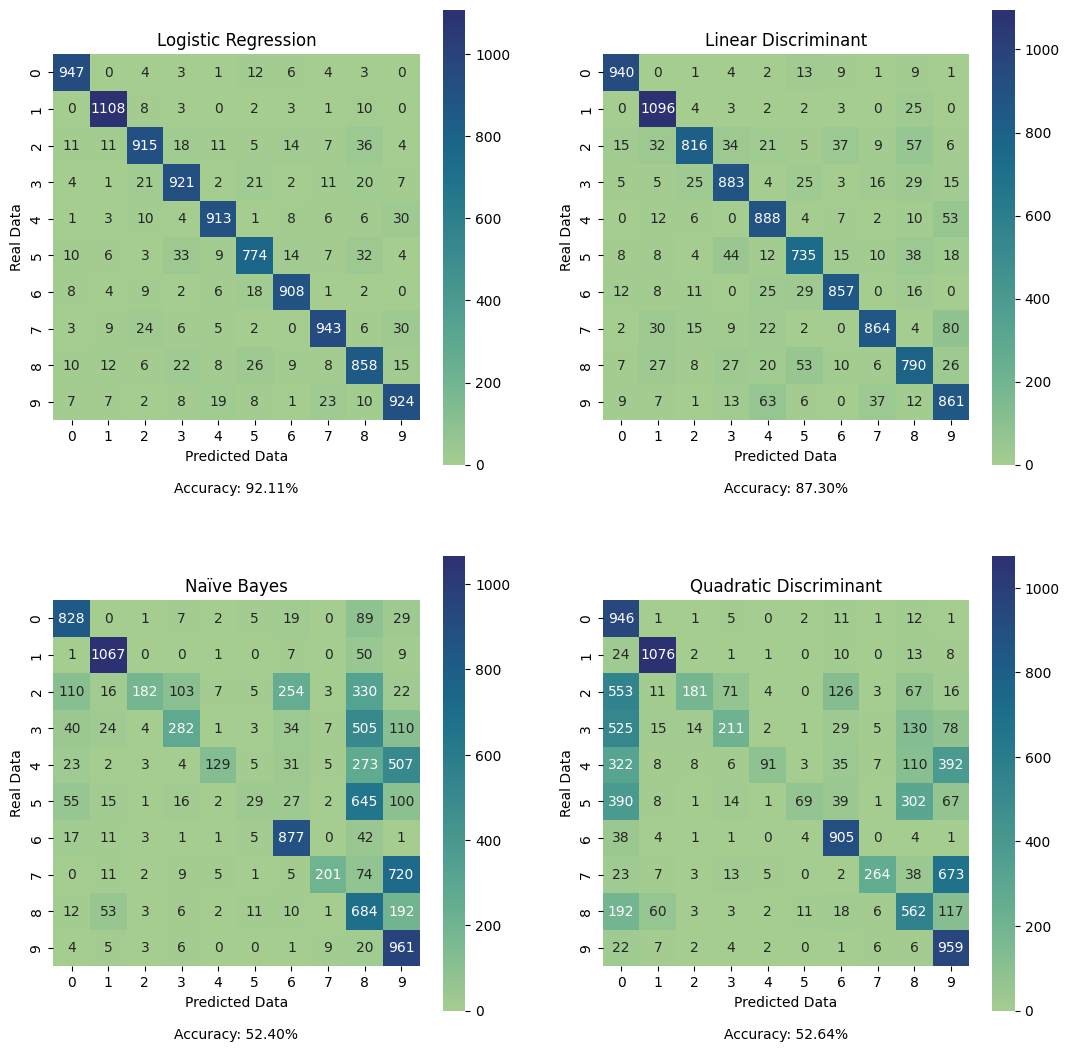

In [ ]:
cm = [[[met.confusion_matrix(y_test, y_log_reg), 'Logistic Regression', log_reg_data[0][1]],
      [met.confusion_matrix(y_test, y_lin_dis), 'Linear Discriminant', lin_dis_data[0][1]]],
      [[met.confusion_matrix(y_test, y_nai_bay), 'Naïve Bayes', nai_bay_data[0][1]],
      [met.confusion_matrix(y_test, y_qua_dis), 'Quadratic Discriminant', qua_dis_data[0][1]]]]

fig, axes = plt.subplots(2, 2, figsize=(13, 13))

for i in range(2):
  for j in range(2):
    sns.heatmap(cm[i][j][0], annot=True, fmt='d', cmap='crest', ax=axes[i][j], square=True, cbar=True)
    axes[i][j].set_title(cm[i][j][1])
    axes[i][j].set_xlabel(f'Predicted Data\n\nAccuracy: {cm[i][j][2]*100:.2f}%')
    axes[i][j].set_ylabel('Real Data')

plt.show()

Após aplicação dos 4 classificadores do *sklearn* na base do *MNIST*, obteve-se os resultados observados nas Matrizes de Confusão acima.

Percebe-se uma acurácia precisa (próxima de 100%) nos modelos usando Regressão Logística e Análise do Discriminante Linear, a qual nos permite visualizar claramente um destaque da diagonal do *Heatmap*, indicando grande acerto desses modelos.

Por outro lado, observa-se também uma acurácia significantemente menor nos modelos de Análise do Discriminante Quadrático e de Naive Bayes Gaussiano. Nesse sentido, apesar de haver certo destaque na diagonal do *Heatmap*, houve muita confusão na identificação de números como 5 e 7, no caso do Naive Bayes, e de números como 2, 3 e 7, no caso do Discriminante Quadrático.

# **CIFAR10**

O *CIFAR10* também é uma biblioteca de imagens com 10 etiquetas do *Keras*, com 50 mil exemplares. Entretanto, em vez de 2 dimensões, são imagens de 3 dimensões (32x32x3). Sua dimensão adicional é referente aos valores de vermelho, verde e azul (RGB) de cada pixel. Ou seja, são imagens coloridas.

Além disso, as imagens do *CIFAR10* não representam números decimais, e sim fotos de objetos e animais com qualidade reduzida para 32x32.

Ao final do trabalho serão abordadas as implicações dessas diferenças nos modelos e em suas previsões.

In [ ]:
from keras.datasets import cifar10
(x_train, y_train),(x_test, y_test) = cifar10.load_data()

In [ ]:
print(f'{x_train.shape}, {y_train.shape}, {x_test.shape}, {y_test.shape}')

(50000, 32, 32, 3), (50000, 1), (10000, 32, 32, 3), (10000, 1)


Nomenclatura e separação semelhantes àquelas do *MNIST*, mas com uma dimensão adicional nos vetores "X".

Além disso, há um erro que faz as listas "Y" terem uma dimensão unitária a mais.

Vamos consertar esse problema utilizando o método *reshape*.

In [ ]:
y_train = y_train.reshape(50000)
y_test = y_test.reshape(10000)
print(f'{x_train.shape}, {y_train.shape}, {x_test.shape}, {y_test.shape}')

(50000, 32, 32, 3), (50000,), (10000, 32, 32, 3), (10000,)


Vamos visualizar 10 exemplos de cada uma das 10 etiquetas disponíveis no *CIFAR10*:

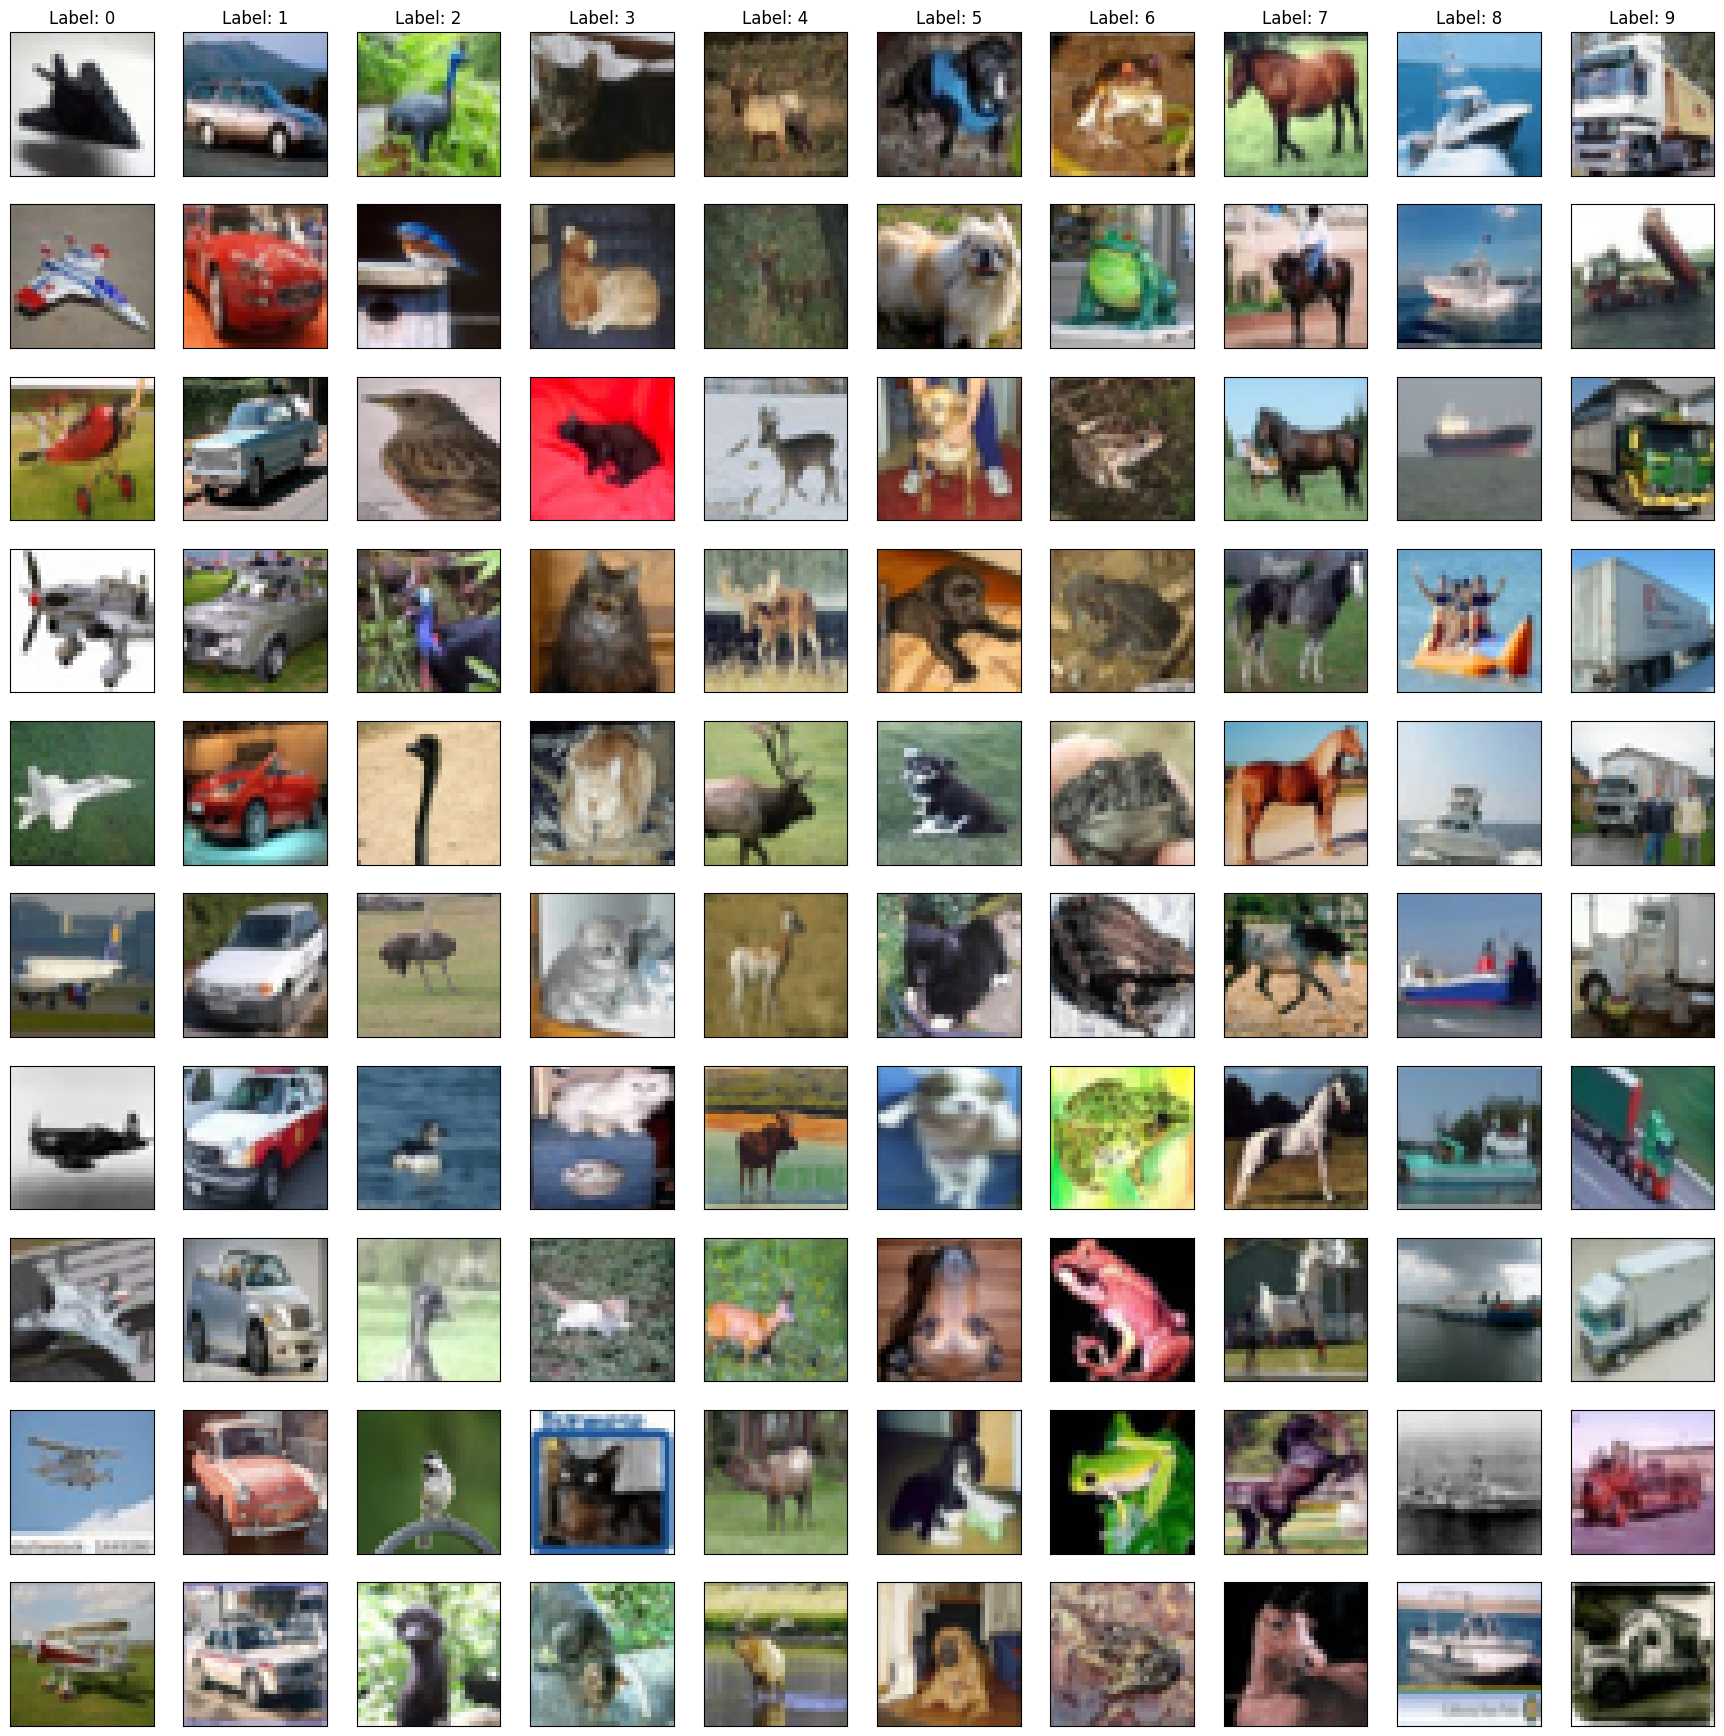

In [ ]:
fig, ax = plt.subplots(10, 10, figsize=(22,22))

for i in range(10):
  for j in range(10):
    sample = x_train[y_train == j][i]
    ax[i][j].imshow(sample)
    if i == 0:
      ax[i][j].set_title(f"Label: {j}")
    ax[i][j].get_xaxis().set_visible(False)
    ax[i][j].get_yaxis().set_visible(False)

Perceba que cada etiqueta é referente a imagens um objeto ou animal da vida real.

Por questões de praticidade e leitura, vamos substituir as listas com etiquetas de 0-9 por uma lista contendo as *strings* referentes aos nomes desses objetos.

In [ ]:
temp = np.concatenate((y_train, y_test))
names = np.full(60000, '     ')
names[temp == 0] = 'Plane'
names[temp == 1] = 'Car'
names[temp == 2] = 'Bird'
names[temp == 3] = 'Cat'
names[temp == 4] = 'Deer'
names[temp == 5] = 'Dog'
names[temp == 6] = 'Frog'
names[temp == 7] = 'Horse'
names[temp == 8] = 'Boat'
names[temp == 9] = 'Truck'
names_train = names[:50000]
names_test = names[50000:]

De forma semelhante ao procedimento realizado com o banco de dados do *MNIST*, é importante aplicar a normalização e a remodelação.

Perceba que a remodelação, nesse caso, tranformará uma lista 32x32x3 em uma lista com 3072 elementos, de dimensão unitária. Ou seja, há uma quantidade significativamente maior de informação para cada imagem do banco de dados.

In [ ]:
scaler = pre.StandardScaler()
scaler.fit(x_train.reshape(50000, 3072))

x_train = scaler.transform(x_train.reshape(50000, 3072))
x_test = scaler.transform(x_test.reshape(10000, 3072))

Agora, partimos para a criação, treinamento, teste e visualização das métricas de desempenho, de forma semelhante ao que foi realizado com o *MNIST*.

# Regressão Logística

In [ ]:
from sklearn import linear_model

log_reg = linear_model.LogisticRegression(random_state=0, solver='sag', multi_class='multinomial', penalty='l2', max_iter=200) # Criação do modelo
log_reg.fit(X = x_train, y = names_train) # Treinamento

/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


LogisticRegression(max_iter=200, multi_class='multinomial', random_state=0,
                   solver='sag')

Diversos testes foram feitos com diferentes *solvers* e número de iterações na Regressão Logística do *sklearn*, mas nenhuma conseguiu convergir propriamente, em razão do grande volume de dados.

Entretanto, como será abordado posteriormente, o modelo ainda conseguiu uma performance aceitável com o *solver* "*Stochastic Average Gradient*" ou "*sag*", e com o mesmo número de iterações utilizado no *MNIST*.

In [ ]:
y_log_reg = log_reg.predict(x_test) # Previsão

In [ ]:
# Métricas de desempenho
log_reg_data = [['Accuracy', met.accuracy_score(names_test, y_log_reg)],
                ['Precision', met.precision_score(names_test, y_log_reg, average='macro')],
                ['Recall', met.recall_score(names_test, y_log_reg, average='macro')],
                ['F1-score', met.f1_score(names_test, y_log_reg, average='macro')]]

acc_cifar10.append(f'{log_reg_data[0][1]*100:.2f}%')

for i in range(len(log_reg_data)):
  print(f'{log_reg_data[i][0]}: {log_reg_data[i][1]:.4f}')

Accuracy: 0.3803
Precision: 0.3780
Recall: 0.3803
F1-score: 0.3786


# Análise do Discriminante Linear

In [ ]:
from sklearn import discriminant_analysis

lin_dis = discriminant_analysis.LinearDiscriminantAnalysis() # Criação do modelo
lin_dis.fit(X = x_train, y = names_train) # Treinamento

LinearDiscriminantAnalysis()

In [ ]:
y_lin_dis = lin_dis.predict(x_test) # Previsão

In [ ]:
# Métricas de desempenho
lin_dis_data = [['Accuracy', met.accuracy_score(names_test, y_lin_dis)],
                ['Precision', met.precision_score(names_test, y_lin_dis, average='macro')],
                ['Recall', met.recall_score(names_test, y_lin_dis, average='macro')],
                ['F1-score', met.f1_score(names_test, y_lin_dis, average='macro')]]

acc_cifar10.append(f'{lin_dis_data[0][1]*100:.2f}%')

for i in range(len(lin_dis_data)):
  print(f'{lin_dis_data[i][0]}: {lin_dis_data[i][1]:.4f}')

Accuracy: 0.3713
Precision: 0.3706
Recall: 0.3713
F1-score: 0.3704


# Análise do Discriminante Quadrático

In [ ]:
qua_dis = discriminant_analysis.QuadraticDiscriminantAnalysis()  # Criação do modelo
qua_dis.fit(X = x_train, y = names_train) # Treinamento

QuadraticDiscriminantAnalysis()

In [ ]:
y_qua_dis = qua_dis.predict(x_test) # Previsão

In [ ]:
# Métricas de desempenho
qua_dis_data = [['Accuracy', met.accuracy_score(names_test, y_qua_dis)],
                ['Precision', met.precision_score(names_test, y_qua_dis, average='macro')],
                ['Recall', met.recall_score(names_test, y_qua_dis, average='macro')],
                ['F1-score', met.f1_score(names_test, y_qua_dis, average='macro')]]

acc_cifar10.append(f'{qua_dis_data[0][1]*100:.2f}%')

for i in range(len(qua_dis_data)):
  print(f'{qua_dis_data[i][0]}: {qua_dis_data[i][1]:.4f}')

Accuracy: 0.3623
Precision: 0.4765
Recall: 0.3623
F1-score: 0.3247


# Naïve Bayes

In [ ]:
from sklearn import naive_bayes

nai_bay = naive_bayes.GaussianNB()  # Criação do modelo
nai_bay.fit(X = x_train, y = names_train) # Treinamento

GaussianNB()

In [ ]:
y_nai_bay = nai_bay.predict(x_test) # Previsão

In [ ]:
# Métricas de desempenho
nai_bay_data = [['Accuracy', met.accuracy_score(names_test, y_nai_bay)],
                ['Precision', met.precision_score(names_test, y_nai_bay, average='macro')],
                ['Recall', met.recall_score(names_test, y_nai_bay, average='macro')],
                ['F1-score', met.f1_score(names_test, y_nai_bay, average='macro')]]

acc_cifar10.append(f'{nai_bay_data[0][1]*100:.2f}%')

for i in range(len(nai_bay_data)):
  print(f'{nai_bay_data[i][0]}: {nai_bay_data[i][1]:.4f}')

Accuracy: 0.2976
Precision: 0.3112
Recall: 0.2976
F1-score: 0.2755


# Matriz de Confusão

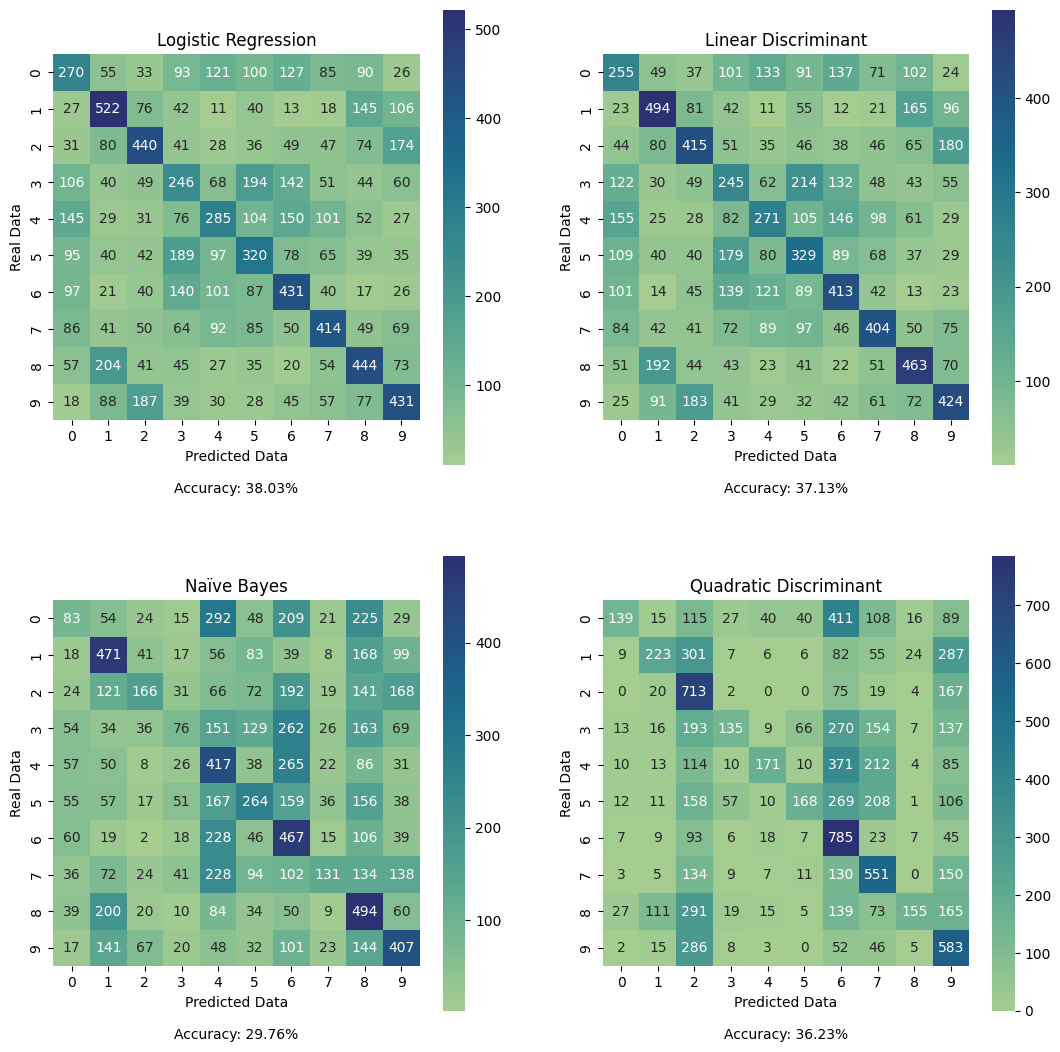

In [ ]:
cm = [[[met.confusion_matrix(names_test, y_log_reg), 'Logistic Regression', log_reg_data[0][1]],
      [met.confusion_matrix(names_test, y_lin_dis), 'Linear Discriminant', lin_dis_data[0][1]]],
      [[met.confusion_matrix(names_test, y_nai_bay), 'Naïve Bayes', nai_bay_data[0][1]],
      [met.confusion_matrix(names_test, y_qua_dis), 'Quadratic Discriminant', qua_dis_data[0][1]]]]

fig, axes = plt.subplots(2, 2, figsize=(13, 13))

for i in range(2):
  for j in range(2):
    sns.heatmap(cm[i][j][0], annot=True, fmt='d', cmap='crest', ax=axes[i][j], square=True, cbar=True)
    axes[i][j].set_title(cm[i][j][1])
    axes[i][j].set_xlabel(f'Predicted Data\n\nAccuracy: {cm[i][j][2]*100:.2f}%')
    axes[i][j].set_ylabel('Real Data')

plt.show()

Após confecção das Matrizes de Confusão, fica perceptível um padrão semelhante ao visto durante o uso da base do *MNIST*. Há uma acurácia maior dos modelos de Regressão Logística e de Análise do Discriminante Linear, que pode ser visto pelo destaque na diagonal do *HeatMap*.

Por outro lado, assim como na análise do *MNIST*, os classificadores Dicriminante Quadrático e Naive Bayes Gaussiano não performaram tão bem, o que gerou outras regiões de destaque no *HeatMap*.

# **Resultados e Análise**

In [ ]:
data = pd.DataFrame(data=[acc_mnist, acc_cifar10], columns=['| Regressão Logística', ' | Análise do Discriminante Linear | ', 'Análise do Discriminante Quadrático | ', 'Naïve Bayes |'], index=['MNIST', 'CIFAR10'])
data.head(2)

,| Regressão Logística,| Análise do Discriminante Linear |,Análise do Discriminante Quadrático |,Naïve Bayes |
MNIST,92.11%,87.30%,52.64%,52.40%
CIFAR10,38.03%,37.13%,36.23%,29.76%


Após testagem de todos os 4 classificadores para cada banco de dados, obteve-se a tabela acima contendo as acurácias de cada execução.

Percebe-se alguns padrões, os quais serão abordados nos tópicos 1 e 2.

# 1.  Diferença entre os Bancos de Dados

Fica clara uma diferença significante entre as acurácias dos classificadores quando utilizaram o *MNIST* ou o *CIFAR10*. Alguns, como o de Regressão Logística, tiveram uma acurácia dobrada no caso do *MNIST*. Essa diferença se dá por 2 motivos principais:
* Há uma diferença colossal no tamanho do conjunto de informação das imagens de cada conjunto. No *MNIST*, são imagens em preto e branco em uma grade 28x28, ou 784 elementos. Já no *CIFAR10*, são imagens coloridas, com 3 gradientes de cor (RGB), em uma grade 32x32, ou seja, um total de 3072 elementos em cada imagem.

  A quantidade quadruplicada de elementos no caso do *CIFAR10* faz com que diferenças sutis em um pixel ou em um conjunto pequeno deles causem diferenças absurdas na estimação de parâmetros durante o treinamento. Assim, durante o teste, há grande imprecisão na classificação.

* No *database* do *CIFAR10*, o conjunto de dados é referente à fotos com qualidade reduzida de objetos e de animais do mundo real, isto é, itens tridimensionais representados em uma grade bidimensional. Isso significa que um objeto pode estar sendo mostrado de frente em uma imagem e de costas em outra, e estas duas serem representações que mudam uma abundância de valores nos pixels.

  Dessa forma, por exemplo, o modelo, ao aprender o que é um cavalo de costas com base nas cores e posições dos pixels que o representam, não necessariamente saberá identificar um cavalo de frente com base nesses mesmos parâmetros. Por isso, surge uma diferença colossal na média das acurácias dos classificadores, que muitas vezes são incapazes de perceber a diferença de angulação em um objeto tridimensional.

# 2.  Funcionamento de cada classificador

É natural a compreensão de que cada um dos 4 classificadores possui mecanismos de estimação e de aprendizado em geral diferentes. Cada um acaba tendo seu uso potencializado em situações específicas, nas quais seus mecanismos trabalhem melhor.

Desse modo, ao utilizar cada um dos 4 para uma mesma tarefa de classificação, é esperado que haja grande contraste entre os resultados.

# **Conclusão**

Após devida aplicação de cada modelo e análise do motivo por trás das diferenças dos resultados, é válido concluir certa superioridade de alguns classificadores em relação a outras para essa tarefa específica.

Nesse contexto, para ambos os bancos de dados, o classificador "Regressão Logística" obteve maior acurácia, além de um claro destaque da diagonal do *HeatMap*.

Já o classificador "Análise do Discriminante Linear", obteve *scores* semelhantes aos da "Regressão Logística", colocando esses dois classificadores como os mais recomendados para a tarefa de classificação dos dois bancos de dados selecionados.

Contudo, observaram-se acurácias medianas ou pequenas dos modelos "Naive Bayes Gaussiano" e "Análise do Discriminante Quadrático" quando comparadas com aquelas dos outros dois modelos. No caso do *CIFAR10*, a diferença não se mostrou muito grande. Já no *MNIST*, ela está próxima de 40%, que pode ser considerado um valor alto. Assim, principalmente na utilização do *MNIST*, esses classificadores não se mostraram os mais recomendados para o nosso objetivo.